# New York Territory Libraries
I'll be analyzing sales for New York territories 

In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
sd = pd.read_csv("StoreDetail.csv")
sd.info()
sd.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 111 entries, 0 to 110
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Store Location     111 non-null    object
 1   State              111 non-null    object
 2   Store ID           111 non-null    int64 
 3   Territory Manager  111 non-null    object
 4   Region             111 non-null    object
 5   Region Director    111 non-null    object
dtypes: int64(1), object(5)
memory usage: 5.3+ KB


,Store Location,State,Store ID,Territory Manager,Region,Region Director
0,Aurora,Colorado,701,Jim Heck,West,Cassie Chambers
1,Berthoud,Colorado,702,Jim Heck,West,Cassie Chambers
2,Boulder,Colorado,703,Jim Heck,West,Cassie Chambers
3,Castle Rock,Colorado,704,Jim Heck,West,Cassie Chambers
4,Denver,Colorado,705,Jim Heck,West,Cassie Chambers


In [4]:
cl = pd.read_csv("customer_list.csv")
cl.info()
cl.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 1 columns):
 #   Column                                           Non-Null Count  Dtype 
---  ------                                           --------------  ----- 
 0   cust_id|date|time|name|email|phone|sms-opt-out   521 non-null    object
dtypes: object(1)
memory usage: 4.2+ KB


,cust_id|date|time|name|email|phone|sms-opt-out
0,1|2023-03-15|08:45:12|Rachel|rachel@centralper...
1,2|2023-05-22|12:30:45|R. Geller|rossg@centralp...
2,3|2023-07-09|18:15:27|Monica Geller|chefmonica...
3,4|2023-09-01|21:05:33|Chandler Bing|chandlerb@...
4,5|2023-11-18|14:22:10|Joey|howyoudoing@central...


In [5]:
ss = pd.read_csv("StoreSales.csv")
ss.info()
ss.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 335129 entries, 0 to 335128
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Transaction Date  335129 non-null  object 
 1   Store ID          335129 non-null  int64  
 2   RewardsID         34943 non-null   float64
 3   Prod Num          335129 non-null  object 
 4   Sale Amount       335129 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 12.8+ MB


,Transaction Date,Store ID,RewardsID,Prod Num,Sale Amount
0,1/1/2022,702,NaN,105349-M,8.00
1,1/1/2022,704,NaN,105350-T,144.00
2,1/1/2022,705,NaN,105351-M,44.00
3,1/1/2022,705,NaN,105352-M,47.61
4,1/1/2022,705,NaN,105353-A,20.36


In [6]:
pc = pd.read_csv("ProductCategories.csv")
pc.info()
pc.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CategoryID     52 non-null     int64 
 1   Category       52 non-null     object
 2   SubcategoryID  52 non-null     object
 3   Subcategory    52 non-null     object
dtypes: int64(1), object(3)
memory usage: 1.8+ KB


,CategoryID,Category,SubcategoryID,Subcategory
0,120,Technology & Accessories,120-tab,Tablets
1,120,Technology & Accessories,120-cal,Calculators
2,120,Technology & Accessories,120-sof,Software Download
3,120,Technology & Accessories,120-hea,Headphones
4,120,Technology & Accessories,120-ext,External Accessories


In [7]:
p = pd.read_csv("Products.csv")
p.info()
p.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 669 entries, 0 to 668
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Prod Num       669 non-null    object
 1   Product        669 non-null    object
 2   CategoryID     669 non-null    int64 
 3   SubcategoryID  669 non-null    object
dtypes: int64(1), object(3)
memory usage: 21.0+ KB


,Prod Num,Product,CategoryID,SubcategoryID
0,105248-IT,TCL NXTPAPER 10s,120,120-tab
1,105249-IT,Dell Latitude 7320 Detachable,120,120-tab
2,105250-IT,Realme Pad,120,120-tab
3,105251-IT,Lenovo Tab P12 Pro,120,120-tab
4,105252-IT,Microsoft Surface Pro 9,120,120-tab


# Core Marketing Analysis

In [8]:
# Who are the territory managers for the sales territories assigned? What are the store IDs and cities
# for the stores in each assigned sales territory?

In [9]:
sd.columns
sd[sd['Territory Manager'] == 'See Ellefson']

,Store Location,State,Store ID,Territory Manager,Region,Region Director
86,Albany,New York,840,See Ellefson,East,Ana Jilani
87,Buffalo,New York,841,See Ellefson,East,Ana Jilani
88,Elmira,New York,842,See Ellefson,East,Ana Jilani
89,Ithaca,New York,843,See Ellefson,East,Ana Jilani
90,Oswego,New York,844,See Ellefson,East,Ana Jilani
91,Plattsburgh,New York,845,See Ellefson,East,Ana Jilani
92,Poestenkill,New York,846,See Ellefson,East,Ana Jilani
93,Rochester,New York,847,See Ellefson,East,Ana Jilani
94,Syracuse,New York,848,See Ellefson,East,Ana Jilani
95,Brooklyn,New York,849,See Ellefson,East,Ana Jilani


In [10]:
#~ this is going to be my like notebook ~
# was only assigned one territory manager and that is "See Ellefson" so I'll pick two different stores to compare.

## comparing two stores in New York

In [11]:
# What is monthly total revenue for in-store sales in each of the two sales territories, over the full 
# period covered by the data
# UHMM I was only given one territory so I'll just compare two random stores in my territory (Adapting :D)

In [12]:
sd = pd.read_csv("StoreDetail.csv")
ss = pd.read_csv("StoreSales.csv")

In [13]:
sd.columns

Index(['Store Location', 'State', 'Store ID', 'Territory Manager', 'Region',
       'Region Director'],
      dtype='object')

In [14]:
ss.columns

Index(['Transaction Date', 'Store ID', 'RewardsID', 'Prod Num', 'Sale Amount'], dtype='object')

In [15]:
data_compare = ss.merge(sd, on="Store ID", how="left") #merging the Store ID since thats the 
#only thing that matches in both csv files

In [16]:
data_compare['Month'] = pd.to_datetime(data_compare['Transaction Date']).dt.to_period('M') # Making the Transaction Date 
#show monthly

In [17]:
data_compare = data_compare[(data_compare['Store ID'] == 849) | 
    (data_compare['Store ID'] == 841)] #Brooklyn vs Buffalo

In [18]:
monthly = (data_compare.groupby(['Month', 'Store ID'])['Sale Amount'].sum().reset_index()) 
#Just like SQL using groupby :D

In [19]:
comparison = monthly.pivot(index='Month',columns='Store ID',values='Sale Amount')

In [20]:
print(comparison) #Lot's of numbers

Store ID       841       849
Month                       
2022-01    4493.19   3094.57
2022-02    2839.50   2270.86
2022-03    3676.72   1842.65
2022-04    1714.81   2010.97
2022-05    5139.71   3173.20
2022-06    4600.58   6285.50
2022-07    2421.53   3944.07
2022-08    2091.17   1541.70
2022-09    4825.59   3233.77
2022-10    2455.58   2875.75
2022-11    9076.33   1665.87
2022-12    2573.69   2435.92
2023-01    5218.02   5690.22
2023-02    5182.18   7169.41
2023-03    6503.58   7908.13
2023-04    5828.43   7606.91
2023-05    8922.16   8184.25
2023-06    9568.07   5589.82
2023-07    8014.50   8206.82
2023-08    7290.82   8870.80
2023-09    5778.55   3444.33
2023-10    6390.79   7344.14
2023-11    7304.37   3701.46
2023-12    4901.26   4914.50
2024-01    5700.39   9135.77
2024-02    6171.23   6190.43
2024-03    5828.43   7643.06
2024-04    8922.16   8148.10
2024-05    9669.65   6298.72
2024-06    7912.92   7497.92
2024-07    7290.82   8870.80
2024-08    5786.55   3591.33
2024-09    638

In [21]:
monthly = monthly.set_index('Month') 

In [22]:
comparison.sum()

Store ID
841    314979.99
849    304732.76
dtype: float64

So there is roughly a 10K difference between Brooklyn and Buffalo. Buffalo being one of the better performing stores.

## Ranking sales by territory

In [23]:
#How would you rank the sales performance of each store in each sales territory? Which are the
#top-performing stores?

I would find all the top performing stores by total revenue period adding the Sales amount in each territory and create a rank list

In [24]:
sd_clean = sd.drop_duplicates(subset='Store ID') #cleaned any duplicates from earlier merge

In [25]:
df = ss.merge(sd_clean, on='Store ID', how='left')

In [26]:
best_store = (df.groupby(['Territory Manager', 'Store ID'])['Sale Amount'].sum().reset_index())

In [27]:
best_store['Rank'] = (best_store.groupby('Territory Manager')['Sale Amount'].rank(ascending=False))

In [28]:
winners = best_store[best_store['Rank'] == 1]

In [29]:
winners.sort_values('Sale Amount',ascending=False)

,Territory Manager,Store ID,Sale Amount,Rank
107,Shruti Reddy,736,8708119.00,1.0
47,Jim Heck,705,917471.53,1.0
36,"Jeff ""Howdy"" Richards",905,637818.90,1.0
85,Miami Vue,835,623163.53,1.0
100,See Ellefson,850,621565.02,1.0
66,Lana Ilana,724,618846.25,1.0
17,Bo Heap,817,602183.44,1.0
73,Len Jensen,853,337002.00,1.0
31,Erbayne Middleton,823,332611.76,1.0
23,Ellen Lemon,870,331116.76,1.0


Based on this info I found, the top top store is store 736 with $8 million worth of sales, It's in Maryland. The sales amount looked crazy big compared to other stores. Which is why I went back to clean duplicates from the earlier merges in the first place to see if the number for that store would go down. But, it didn't so that store just has very good sales performance.

## Best Customers

In [30]:
# Comparing the customer ID from the customer list data with the rewards ID from the sales data,
# who were the top customers in each sales territory? #(The csv file imported wrong so I did google how to fix it :D)

In [31]:
customers = pd.read_csv("customer_list.csv", sep='|')

In [32]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 521 entries, 0 to 520
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   cust_id       521 non-null    int64 
 1   date          521 non-null    object
 2   time          521 non-null    object
 3   name          521 non-null    object
 4   email         521 non-null    object
 5   phone         520 non-null    object
 6   sms-opt-out   520 non-null    object
dtypes: int64(1), object(6)
memory usage: 28.6+ KB


In [33]:
customer_sales = df.merge(customers,left_on='RewardsID',right_on='cust_id',how='left') 
# merged data connecting customer ID and rewards ID

In [34]:
big_spenders = (customer_sales.groupby(['Territory Manager', 'name'])['Sale Amount'].sum().reset_index())
# using .groupby() so the data is organized

In [35]:
big_spenders['Rank'] = (big_spenders.groupby('Territory Manager')['Sale Amount'].rank(ascending=False))

In [36]:
big_spenders = big_spenders[big_spenders['Rank'] == 1]

In [37]:
big_spenders.sort_values('Sale Amount',ascending=False)

,Territory Manager,name,Sale Amount,Rank
2178,Jim Heck,Gloria Mendoza,7855.66,1.0
4459,Shruti Reddy,Cole Brown,7602.28,1.0
4099,See Ellefson,Julian Bashir,6039.32,1.0
1842,"Jeff ""Howdy"" Richards",Nate Jacobs,5240.86,1.0
3516,Miami Vue,Gus Fring,5005.07,1.0
2974,Lana Ilana,Stanley H.,4954.99,1.0
48,Bo Heap,Beverly Crusher,4758.92,1.0
830,Ellen Lemon,Marie S.,4388.87,1.0
1395,Erbayne Middleton,Rosita,3637.75,1.0
3164,Len Jensen,Jin Kwon,1786.05,1.0


So to get all this I just did the same thing I did to find the top performing stores. Gloria Mendoza is the winner for top customer. They spent $7,855.66. She's also in Jim Heck's Territory. (side note: Nate Jacobs on this list is so funny)

## Products

In [38]:
# What is the number of transactions per month by product category in each assigned territory?
# What is total sales revenue per month by category? What might this tell you about the most
# popular products, and where could there be opportunity for growth?

In [39]:
pc = pd.read_csv("ProductCategories.csv")
sd = pd.read_csv("StoreDetail.csv")
ss = pd.read_csv("StoreSales.csv")
p = pd.read_csv("Products.csv")

In [40]:
pc.columns

Index(['CategoryID', 'Category', 'SubcategoryID', 'Subcategory'], dtype='object')

In [41]:
sd.columns

Index(['Store Location', 'State', 'Store ID', 'Territory Manager', 'Region',
       'Region Director'],
      dtype='object')

In [42]:
ss.columns

Index(['Transaction Date', 'Store ID', 'RewardsID', 'Prod Num', 'Sale Amount'], dtype='object')

In [43]:
p.columns

Index(['Prod Num', 'Product', 'CategoryID', 'SubcategoryID'], dtype='object')

In [44]:
# I wan't to do the same with .groupby and .merge() as I did before.To find the store
# sales but just for products and sales and Territory managers. (mental note for self)

In [45]:
ss['Transaction Date'] = pd.to_datetime(ss['Transaction Date'])

In [46]:
ss['Month'] = ss['Transaction Date'].dt.to_period('M')

In [47]:
merged = (ss.merge(p, on='Prod Num').merge(pc, on=['CategoryID', 'SubcategoryID'])
    .merge(sd, on='Store ID'))

In [48]:
buys = (merged.groupby(['Territory Manager', 'Month', 'Category'])['Prod Num'].count()
    .reset_index(name='Transactions'))
rev = (merged.groupby(['Territory Manager', 'Month', 'Category'])['Sale Amount'].sum()
    .reset_index(name='Total_Rev'))

In [49]:
monthly = buys.merge(rev,on=['Territory Manager', 'Month', 'Category'])

In [53]:
monthly

,Territory Manager,Month,Category,Transactions,Total_Rev
0,Bo Heap,2022-01,Apparel and Merchandise,83,3008.15
1,Bo Heap,2022-01,Art Supplies,111,3464.11
2,Bo Heap,2022-01,Books (General),41,1062.65
3,Bo Heap,2022-01,Stationery and Supplies,106,1138.12
4,Bo Heap,2022-01,Technology & Accessories,112,48949.88
...,...,...,...,...,...
2875,Shruti Reddy,2025-12,Art Supplies,408,12541.45
2876,Shruti Reddy,2025-12,Books (General),387,12034.48
2877,Shruti Reddy,2025-12,Stationery and Supplies,467,4612.53
2878,Shruti Reddy,2025-12,Technology & Accessories,539,248633.40


With this data the top category overall the other categories is Tech & Accessories

In [54]:
monthly.sort_values('Total_Rev',ascending=False).head()

,Territory Manager,Month,Category,Transactions,Total_Rev
2866,Shruti Reddy,2025-10,Technology & Accessories,558,266073.43
1426,Jim Heck,2025-10,Technology & Accessories,505,257001.19
2878,Shruti Reddy,2025-12,Technology & Accessories,539,248633.40
2872,Shruti Reddy,2025-11,Technology & Accessories,477,233968.76
2860,Shruti Reddy,2025-09,Technology & Accessories,470,232711.04


I wanted to go a little more into how much the top tech & accessories make each month with Shruti Reddy 

##  Recommendations

I recomend focusing more on Tech & Accessories since that is the top category amongst customer purchases. I would 
also recomend on Top territory too. And based on both data seeing the top store and top category sales the territory manager Shruti Reddy is someone to be in contact with based on performance.

## Charts

I rather put my charts at the end because it just makes sense to me

In [55]:
import matplotlib.pyplot as plt

In [57]:
top_cat = (merged.groupby('Category')['Sale Amount'].sum().sort_values(ascending=False))

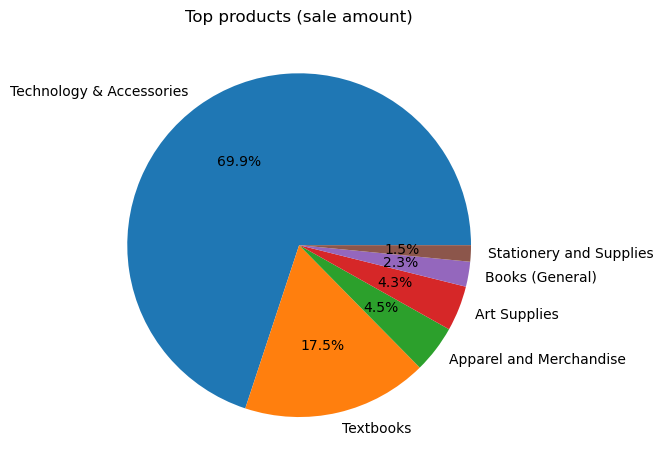

In [104]:
top_cat.plot(kind='pie', autopct='%1.1f%%') 
plt.title('Top products (sale amount)')
plt.ylabel('')
plt.tight_layout()
plt.show()

In [75]:
top_categories # Just checking the numbers

Category
Technology & Accessories    31891406.58
Textbooks                    7961357.21
Apparel and Merchandise      2043382.60
Art Supplies                 1938358.84
Books (General)              1070718.51
Stationery and Supplies       702088.52
Name: Sale Amount, dtype: float64

In [76]:
top_territories = (merged.groupby('Territory Manager')['Sale Amount'].sum().sort_values(ascending=False))

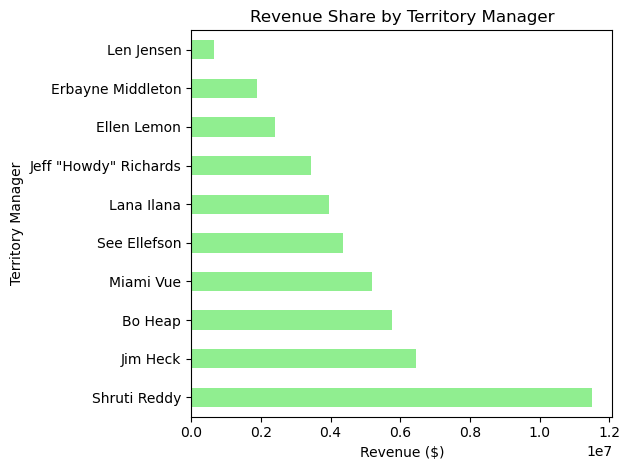

In [103]:
top_territories.plot(kind='barh',color='lightgreen')
plt.title('Revenue Share by Territory Manager')
plt.xlabel('Revenue ($)')
plt.ylabel('Territory Manager')
plt.tight_layout()
plt.show()

Thank you for your time :D